<a href="https://colab.research.google.com/github/nkreuzer26/Milestone_3/blob/main/NK_Milestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Control Analysis: Economic Impact of the 1973 Chilean Coup

## Introduction

This notebook applies the Synthetic Control Method (SCM) to estimate the economic impact of Chile's 1973 military coup and subsequent authoritarian regime under General Augusto Pinochet. Using a similar approach to my replication study evaluating Colombia's cartel violence, I construct a counterfactual "Synthetic Chile" from a weighted combination of comparable countries that did not experience a military coup in 1973.

The synthetic control method allows us to estimate what Chile's economic trajectory would have been in the absence of the 1973 intervention by matching Chile's pre-1973 economic characteristics with a weighted average of donor countries. The difference between Chile's observed GDP per capita and this synthetic counterfactual provides an estimate of the coup's economic impact.

This code/milestone will be part of my final project examining the economic consequences of U.S. backed interventions in Latin America (specifically focusing on regime-changes and not full-blown military interventions). I ultimately plan to use this as a template for analyzing similar interventions in Argentina (1976) and Guatemala (1954) to expand the implications to multiple Latin American countries.   

This approach includes several steps: (1) constructing an appropriate donor pool of comparable countries, (2) collecting economic and demographic predictors for the pre-treatment period (1960-1972), (3) estimating optimal donor weights to construct Synthetic Chile, (4) evaluating pre-treatment fit quality, and (5) calculating post-treatment effects across different time periods of the Pinochet regime and democratic transition.

# Initial Data Setup and Parameters
Before constructing the donor pool, I define the parameters for the Chile analysis and load the GDP data. The pre-treatment period (1960–1972) includes Chile's economic trajectory before the 1973 military coup, allowing the synthetic control to learn Chile's pre-intervention characteristics. The intervention year incorporates September 11, 1973, when the Pinochet regime began. The post-treatment window extends through 2000, covering both the authoritarian period and the beginning of the restored democracy years.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define analysis parameters
TREATED_COUNTRY = "Chile"
INTERVENTION_YEAR = 1973
PRE_TREATMENT_START = 1960
PRE_TREATMENT_END = 1972
POST_TREATMENT_START = 1973
POST_TREATMENT_END = 2000

# Load Maddison Project Database
maddison_data = pd.read_excel("mpd2023_web.xlsx", sheet_name="Full data")

# Filter to study period (1960-2000)
maddison_data = maddison_data[
    (maddison_data["year"] >= PRE_TREATMENT_START) &
    (maddison_data["year"] <= POST_TREATMENT_END)
].copy()

# Screening Potential Donor Countries by GDP
Following the approach of the Colombia study, I filtered countries based on their pre-treatment GDP per capita to identify economically comparable nations. I use 1972 GDP data from the Maddison Project Database, representing the last complete year before the September 1973 coup.

Unlike the Colombia study which used percentile-based filtering (excluding the richest and poorest 30% of countries), I used a ratio-based approach for Chile. This is because Chile's 1972 GDP per capita of ~$8,500 puts it in a higher income bracket than Colombia in 1975, and a ratio-based filter more effectively identifies countries with similar economic development levels. Countries with GDP between 60% and 150% of Chile's level are retained as potential donors, ensuring the donor pool includes nations both slightly poorer and slightly richer than Chile while excluding extreme cases.

In [2]:
# Extract 1972 GDP per capita for all countries
gdp_1972 = (
    maddison_data.loc[maddison_data["year"] == 1972, ["country", "year", "gdppc"]]
    .dropna(subset=["gdppc"])
    .copy()
)

# Get Chile's 1972 GDP per capita
chile_gdp_1972 = maddison_data[
    (maddison_data["country"] == "Chile") &
    (maddison_data["year"] == 1972)
]["gdppc"].values[0]

# Calculate GDP ratio relative to Chile for each country
gdp_1972["gdp_ratio_to_chile"] = gdp_1972["gdppc"] / chile_gdp_1972

# Filter countries between 60% and 150% of Chile's GDP
comparable_countries = gdp_1972[
    (gdp_1972["gdp_ratio_to_chile"] >= 0.6) &
    (gdp_1972["gdp_ratio_to_chile"] <= 1.5)
].copy()

print(f"Countries after GDP screening: {len(comparable_countries)}")
print(f"GDP range: ${comparable_countries['gdppc'].min():,.0f} - ${comparable_countries['gdppc'].max():,.0f}")
print(f"Chile's 1972 GDP: ${chile_gdp_1972:,.0f}")

Countries after GDP screening: 43
GDP range: $5,128 - $12,170
Chile's 1972 GDP: $8,520


# Applying Exclusion Criteria to Construct the Donor Pool
I apply systematic exclusion criteria to ensure donor countries are plausibly comparable to Chile before 1973. Countries are removed if they experienced similar political interventions, had fundamentally different economic structures, or lacked stable pre-treatment periods that could serve as valid counterfactuals.

The exclusion logic is adapted to Chile's specific context. Unlike the Colombia study which excluded countries with high terrorism due to the cartel violence treatment, this analysis excludes Latin American countries that experienced military coups or authoritarian transitions during the 1970s, as these represent similar treatments that could contaminate the donor pool. Socialist command economies, oil-dependent states, and rapidly-growing Asian Tiger economies are also excluded following the original study's rationale. Additionally, countries with insufficient data for the predictor variables are also excluded.

In [3]:
# Define exclusion criteria adapted from Colombia study's Table A.1
EXCLUSION_CRITERIA = {
    # Treated country
    "Chile": "Treated country",

    # Latin American military regimes and coups (parallel treatments)
    "Argentina": "Military coup 1976, Dirty War",
    "Uruguay": "Military coup 1973, contemporaneous with Chile",
    "Brazil": "Military dictatorship 1964-1985",
    "Peru": "Military government, high terrorism",
    "Bolivia": "Multiple military coups, political instability",
    "Guatemala": "Military government, civil war",
    "El Salvador": "Civil war 1979-1992, high terrorism",
    "Nicaragua": "Sandinista revolution 1979, high terrorism",
    "Panama": "Military regime, US intervention 1989",

    # Socialist and state-directed economies
    "Poland": "Socialist 1952-1989",
    "Hungary": "Socialist 1949-1989",
    "Syria": "Socialist 1963-2012",
    "Syrian Arab Republic": "Socialist 1963-2012",  # ADDED: actual name in data
    "Iraq": "Socialist 1968-2003",
    "Libya": "Socialist 1969-2011",
    "Romania": "Socialist 1947-1989",
    "Seychelles": "Socialist 1977-1992",
    "Tunisia": "Socialist 1963-2012",
    "Cuba": "Socialist 1976-present",
    "Albania": "Socialist 1944-1992",
    "Congo": "Socialist 1969-1992",
    "Yemen": "Socialist 1967-1990",
    "Former USSR": "Socialist command economy 1922-1991",
    "Russian Federation": "Anachronistic (USSR during study period)",
    "Czechoslovakia": "Socialist 1948-1989",
    "Czech Republic": "Former Czechoslovakia, socialist 1948-1989",  # ADDED
    "Bulgaria": "Socialist 1946-1990",
    "Croatia": "Part of socialist Yugoslavia 1945-1991",
    "Former Yugoslavia": "Socialist federation 1945-1991",  # ADDED
    "Yugoslavia": "Socialist federation 1945-1991",  # ADDED: alternative name

    # Other authoritarian regimes with parallel transitions
    "Turkey": "Military coups, high terrorism",
    "South Africa": "Apartheid regime, high terrorism",
    "Philippines": "Marcos martial law 1972",

    # Civil wars and armed conflicts
    "Lebanon": "Civil war 1975-1990, high terrorism",
    "Sri Lanka": "Tamil insurgency, high terrorism",
    "Djibouti": "Civil war 1991-1994",
    "Liberia": "Civil war 1989-1996",
    "Namibia": "UNITA conflict spillover",
    "Swaziland": "ANC cross-border conflicts",

    # Regional conflicts (Middle East and Persian Gulf)
    "Jordan": "Regional wars, refugee crises",
    "Palestine": "Israeli-Palestinian conflict",
    "Bahrain": "Persian Gulf regional instability",
    "Egypt": "Regional conflicts, Yom Kippur War",

    # Oil-dependent and resource economies
    "Ecuador": "OPEC member, oil-dependent",
    "Algeria": "OPEC member, oil-dependent",
    "Equatorial Guinea": "Oil economy",
    "Gabon": "Oil economy",
    "Oman": "Oil economy, Dhofar Rebellion 1962-1976",
    "Iran (Islamic Republic of)": "Oil economy, Islamic Revolution 1979",

    # Asian Tiger and Tiger Cub economies
    "Taiwan": "Asian Tiger, extraordinary growth",
    "Malaysia": "Tiger Cub economy",
    "Thailand": "Tiger Cub economy",
    "Indonesia": "Tiger Cub economy",
    "Singapore": "City-state, Tiger economy",

    # City-states and territories (structurally non-comparable)
    "Hong Kong": "City-state, British colony",
    "China, Hong Kong SAR": "City-state, British colony",  # ADDED: actual name in data
    "Puerto Rico": "US territory, federal transfers",
    "Cyprus": "Small island, Turkish invasion 1974",
    "Mauritius": "Small island economy",
    "Barbados": "Small island economy",

    # Severe economic crises
    "Cote d'Ivoire": "Economic crisis, political instability",

    # Insufficient data
    "Jamaica": "Incomplete predictor coverage",
    "Saint Lucia": "Incomplete predictor coverage",
    "Honduras": "Incomplete data, political instability",

    # Post-1990s states (anachronistic)
    "Bosnia and Herzegovina": "Post-Yugoslav state",
    "Serbia": "Post-Yugoslav state",
    "Montenegro": "Post-Yugoslav state",
    "Macedonia": "Post-Yugoslav state",
    "TFYR of Macedonia": "Post-Yugoslav state",  # ADDED: actual name in data
}

# Apply exclusions to GDP-screened countries
candidate_countries = comparable_countries[
    ~comparable_countries["country"].isin(EXCLUSION_CRITERIA.keys())
].copy()

print(f"Countries after exclusions: {len(candidate_countries)}")
print("\nFinal candidate donor pool:")
print(candidate_countries[["country", "gdppc", "gdp_ratio_to_chile"]].sort_values("gdppc", ascending=False))

Countries after exclusions: 7

Final candidate donor pool:
          country         gdppc  gdp_ratio_to_chile
47285      Greece  11795.000000            1.384390
37197       Spain  10787.692666            1.266161
54269     Ireland  10621.000000            1.246596
97725    Portugal  10130.000000            1.188967
75997      Mexico   7256.000000            0.851643
27109  Costa Rica   6564.000000            0.770423
24781    Colombia   5348.000000            0.627700


# Data Validation

Before moving on, I verify that the candidate donor pool GDP distribution is balanced around Chile. A good donor pool should include countries both above and below Chile's income level, ensuring the synthetic control algorithm has flexibility to match Chile's pre-treatment trajectory without being constrained to either systematically wealthier or poorer countries.

In [4]:
# Display donor pool summary statistics
print(f"Final candidate donor pool: {len(candidate_countries)} countries\n")
print(f"Chile's 1972 GDP: ${chile_gdp_1972:,.0f}")
print(f"Donor GDP range: ${candidate_countries['gdppc'].min():,.0f} - ${candidate_countries['gdppc'].max():,.0f}")
print(f"Donor GDP median: ${candidate_countries['gdppc'].median():,.0f} ({candidate_countries['gdppc'].median()/chile_gdp_1972*100:.1f}% of Chile)")

# Verify balanced distribution around Chile
above_chile = candidate_countries[candidate_countries['gdppc'] > chile_gdp_1972]
below_chile = candidate_countries[candidate_countries['gdppc'] < chile_gdp_1972]

print(f"\nDonors above Chile's GDP: {len(above_chile)} ({len(above_chile)/len(candidate_countries)*100:.1f}%)")
print(f"Donors below Chile's GDP: {len(below_chile)} ({len(below_chile)/len(candidate_countries)*100:.1f}%)")

print("\nCandidate donor countries:")
for country in candidate_countries.sort_values('gdppc', ascending=False)['country']:
    print(f"  {country}")

Final candidate donor pool: 7 countries

Chile's 1972 GDP: $8,520
Donor GDP range: $5,348 - $11,795
Donor GDP median: $10,130 (118.9% of Chile)

Donors above Chile's GDP: 4 (57.1%)
Donors below Chile's GDP: 3 (42.9%)

Candidate donor countries:
  Greece
  Spain
  Ireland
  Portugal
  Mexico
  Costa Rica
  Colombia


# Visualizing Pre-Treatment GDP Trajectories
Before collecting predictor variables, I examine the pre-treatment GDP trajectories of Chile and the final donor pool. This checks that donor countries have plausibly similar economic trends during 1960-1972. Countries with dramatically different growth patterns or GDP levels would suggest potential issues with the donor pool construction though the final synthetic control weights should account for differences through the optimization process.

Filtered Maddison data: 6929 rows
Year range: 1960 to 2000
Analysis panel: 328 rows, 8 countries

Checking data completeness (1960-2000):

Final donor pool: 7 countries
['Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']


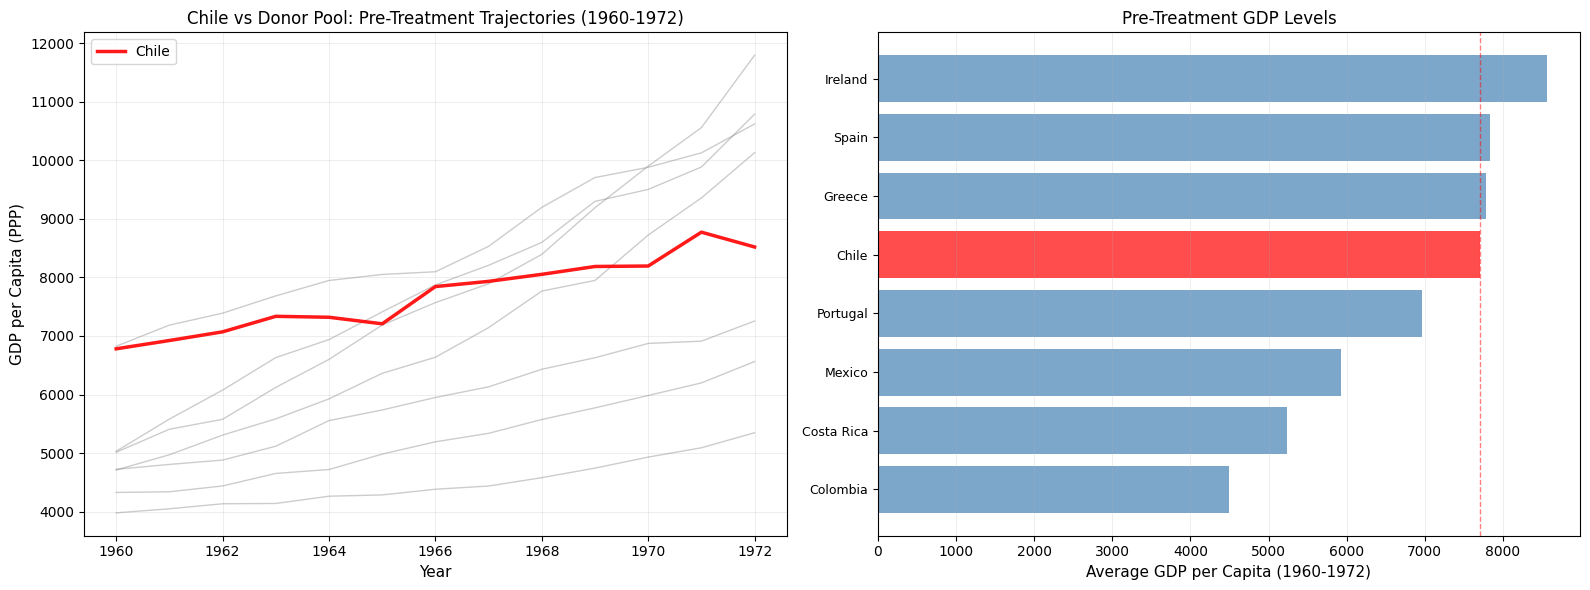


Pre-treatment GDP summary (1960-1972):
  Chile: $7,703
  Donor range: $4,490 - $8,557
  Donor median: $6,967 (90.4% of Chile)


In [5]:
# Filter maddison_data to study period
maddison_data_filtered = maddison_data[
    (maddison_data["year"] >= PRE_TREATMENT_START) &
    (maddison_data["year"] <= POST_TREATMENT_END)
].copy()

print(f"Filtered Maddison data: {len(maddison_data_filtered)} rows")
print(f"Year range: {maddison_data_filtered['year'].min()} to {maddison_data_filtered['year'].max()}")

# Create list of countries for analysis
countries_of_interest = [TREATED_COUNTRY] + candidate_countries["country"].tolist()

# Build analysis panel with filtered data
analysis_panel = maddison_data_filtered[
    maddison_data_filtered["country"].isin(countries_of_interest)
].copy()

print(f"Analysis panel: {len(analysis_panel)} rows, {analysis_panel['country'].nunique()} countries")

# Verify data completeness for each country
expected_years = set(range(PRE_TREATMENT_START, POST_TREATMENT_END + 1))
final_donor_pool = []

print("\nChecking data completeness (1960-2000):")
for country in candidate_countries["country"]:
    country_data = analysis_panel[analysis_panel["country"] == country]
    available_years = set(country_data["year"].unique())

    if expected_years - available_years:
        print(f"  Excluding {country}: incomplete year coverage")
        continue

    if country_data["gdppc"].isna().any():
        missing_count = country_data["gdppc"].isna().sum()
        print(f"  Excluding {country}: {missing_count} missing GDP values")
        continue

    final_donor_pool.append(country)

print(f"\nFinal donor pool: {len(final_donor_pool)} countries")
print(final_donor_pool)

# Filter analysis panel to only include countries with complete data
analysis_panel = analysis_panel[
    analysis_panel["country"].isin([TREATED_COUNTRY] + final_donor_pool)
].copy()

# Convert to wide format for visualization
gdp_panel = analysis_panel.pivot(
    index="year",
    columns="country",
    values="gdppc"
)

# plot two-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Chile vs all donor trajectories
pre_treatment_data = gdp_panel.loc[PRE_TREATMENT_START:PRE_TREATMENT_END]

ax1.plot(pre_treatment_data.index, pre_treatment_data[TREATED_COUNTRY],
         color='red', linewidth=2.5, label='Chile', alpha=0.9, zorder=10)

for donor in final_donor_pool:
    ax1.plot(pre_treatment_data.index, pre_treatment_data[donor],
             color='gray', alpha=0.4, linewidth=1)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('GDP per Capita (PPP)', fontsize=11)
ax1.set_title('Chile vs Donor Pool: Pre-Treatment Trajectories (1960-1972)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, linewidth=0.5)

# Panel 2: Average GDP comparison
avg_gdp_pre = pre_treatment_data.mean().sort_values(ascending=True)

colors = ['red' if c == TREATED_COUNTRY else 'steelblue' for c in avg_gdp_pre.index]
ax2.barh(range(len(avg_gdp_pre)), avg_gdp_pre.values, color=colors, alpha=0.7)
ax2.set_yticks(range(len(avg_gdp_pre)))
ax2.set_yticklabels(avg_gdp_pre.index, fontsize=9)
ax2.set_xlabel('Average GDP per Capita (1960-1972)', fontsize=11)
ax2.set_title('Pre-Treatment GDP Levels', fontsize=12)
ax2.axvline(avg_gdp_pre[TREATED_COUNTRY], color='red', linestyle='--',
            alpha=0.5, linewidth=1)
ax2.grid(axis='x', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

# Summary stats
chile_avg_gdp = avg_gdp_pre[TREATED_COUNTRY]
donor_avg_gdps = avg_gdp_pre.drop(TREATED_COUNTRY)

print(f"\nPre-treatment GDP summary (1960-1972):")
print(f"  Chile: ${chile_avg_gdp:,.0f}")
print(f"  Donor range: ${donor_avg_gdps.min():,.0f} - ${donor_avg_gdps.max():,.0f}")
print(f"  Donor median: ${donor_avg_gdps.median():,.0f} ({donor_avg_gdps.median()/chile_avg_gdp*100:.1f}% of Chile)")

# Predictor Variable #1: GDP per Capita
The first predictor used in the synthetic control model is average GDP per capita during the pre-treatment period. GDP is averaged over 1960–1972 to capture Chile's economic level before the 1973 coup. This allows the synthetic control algorithm to make a counterfactual from donor countries with similar pre-intervention income levels.

In [6]:
# Calculate average GDP per capita for the pre-treatment period
pre_treatment_period = analysis_panel[
    (analysis_panel["year"] >= PRE_TREATMENT_START) &
    (analysis_panel["year"] <= PRE_TREATMENT_END)
].copy()

gdp_predictor = (
    pre_treatment_period
    .groupby("country")["gdppc"]
    .mean()
    .reset_index()
)

# Convert to wide format where each country becomes a column
predictor_matrix = gdp_predictor.set_index("country").T
predictor_matrix.index = ["GDP_avg_1960_1972"]

predictor_matrix

country,Chile,Colombia,Costa Rica,Greece,Ireland,Mexico,Portugal,Spain
GDP_avg_1960_1972,7703.384615,4490.076923,5237.538462,7785.461538,8557.384615,5923.461538,6967.230769,7832.719085


# Predictor Variable #2: Human Capital Index
The second predictor is the Human Capital Index from the Penn World Table, which measures the productivity of a country's workforce based on educational attainment and returns to schooling. HCI captures the skill level and knowledge of the labor force, representing human capital accumulation that drives economic productivity. Including the Human Capital Index ensures the synthetic control is constructed from countries with similar workforce quality to Chile during the pre-treatment period, accounting for differences in education and skill development that affect long-term economic growth potential.

In [7]:
# Load Penn World Table data
pwt_data = pd.read_excel("pwt110.xlsx", sheet_name="Data")

# Filter to countries in the analysis
pwt_analysis = pwt_data[pwt_data["country"].isin(countries_of_interest)].copy()

# Restrict to pre-treatment period
pwt_pre_treatment = pwt_analysis[
    (pwt_analysis["year"] >= PRE_TREATMENT_START) &
    (pwt_analysis["year"] <= PRE_TREATMENT_END)
].copy()

# Calculate average Human Capital Index for each country
human_capital_predictor = (
    pwt_pre_treatment
    .groupby("country")["hc"]
    .mean()
    .reset_index()
)

# Convert to wide format and add to predictor matrix
human_capital_row = human_capital_predictor.set_index("country").T
human_capital_row.index = ["HumanCapital_avg_1960_1972"]

predictor_matrix = pd.concat([predictor_matrix, human_capital_row])

predictor_matrix

country,Chile,Colombia,Costa Rica,Greece,Ireland,Mexico,Portugal,Spain
GDP_avg_1960_1972,7703.384615,4490.076923,5237.538462,7785.461538,8557.384615,5923.461538,6967.230769,7832.719085
HumanCapital_avg_1960_1972,2.052958,1.643274,1.656109,2.039948,2.346504,1.672438,1.358225,2.009300


# Predictor Variable #3: Years of Schooling
The third predictor is the average years of schooling in the adult population, drawn from the Barro-Lee Educational Attainment Dataset. This measures the average amount of formal education completed by adults aged 25 and above, serving as a proxy for the overall educational attainment and skill level of the workforce. Educational attainment is linked to labor productivity, technological adoption, and long-term economic growth. Countries with similar schooling levels are more likely to share comparable economic development paths, making this variable useful for constructing a synthetic control that captures Chile's educational characteristics before 1973.

In [8]:
# Load Barro-Lee educational attainment data
schooling_data = pd.read_excel(
    "BL2013_MF2599_v2.2.xls",
    sheet_name="Sheet1",
    header=7
)

# Forward-fill country names (source file uses merged cells)
schooling_data["Country"] = schooling_data["Country"].ffill()
schooling_data = schooling_data[schooling_data["Country"].notna()].copy()

# Standardize column names
schooling_data = schooling_data.rename(columns={
    "Country": "country",
    "Year": "year",
    "Avg. Years of Total Schooling": "school_years"
})[["country", "year", "school_years"]]

# Filter to analysis countries
schooling_analysis = schooling_data[
    schooling_data["country"].isin(countries_of_interest)
].copy()

# Restrict to pre-treatment period
schooling_pre_treatment = schooling_analysis[
    (schooling_analysis["year"] >= PRE_TREATMENT_START) &
    (schooling_analysis["year"] <= PRE_TREATMENT_END)
].copy()

# Calculate average years of schooling for each country
schooling_predictor = (
    schooling_pre_treatment
    .groupby("country")["school_years"]
    .mean()
    .reindex(countries_of_interest)
)

# Convert to wide format and add to predictor matrix
schooling_row = schooling_predictor.to_frame().T
schooling_row.index = ["Schooling_avg_1960_1972"]

predictor_matrix = pd.concat([predictor_matrix, schooling_row])

predictor_matrix

country,Chile,Colombia,Costa Rica,Greece,Ireland,Mexico,Portugal,Spain
GDP_avg_1960_1972,7703.384615,4490.076923,5237.538462,7785.461538,8557.384615,5923.461538,6967.230769,7832.719085
HumanCapital_avg_1960_1972,2.052958,1.643274,1.656109,2.039948,2.346504,1.672438,1.358225,2.009300
Schooling_avg_1960_1972,5.366667,3.080000,3.720000,6.323333,6.806667,2.586667,2.216667,4.046667


# Predictor Variable #4: Inflation Rate
The fourth predictor is the average annual consumer price inflation rate, measuring macroeconomic stability during the pre-treatment period. Inflation reflects the stability of a country's monetary policy, fiscal discipline, and overall macroeconomic management. Countries experiencing similar inflation rates are more likely to share comparable economic policy and growth trajectories. Including inflation in the predictor matrix ensures that the synthetic control is constructed from countries with similar macroeconomic conditions to Chile before 1973, accounting for differences in price stability that could affect economic performance.

In [9]:
# Load consumer price inflation data from Our World in Data
inflation_data = pd.read_csv("inflation-of-consumer-prices.csv")

# Standardize column names
inflation_data = inflation_data.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Inflation, consumer prices (annual %)": "inflation"
})

# Filter to analysis countries
inflation_analysis = inflation_data[
    inflation_data["country"].isin(countries_of_interest)
].copy()

# Restrict to pre-treatment period
inflation_pre_treatment = inflation_analysis[
    (inflation_analysis["year"] >= PRE_TREATMENT_START) &
    (inflation_analysis["year"] <= PRE_TREATMENT_END)
].copy()

# Calculate average inflation for each country
inflation_predictor = (
    inflation_pre_treatment
    .dropna(subset=["inflation"])
    .groupby("country")["inflation"]
    .mean()
    .reindex(countries_of_interest)
)

# Convert to wide format and add to predictor matrix
inflation_row = inflation_predictor.to_frame().T
inflation_row.index = ["Inflation_avg_1960_1972"]

predictor_matrix = pd.concat([predictor_matrix, inflation_row])

predictor_matrix

country,Chile,Colombia,Costa Rica,Greece,Ireland,Mexico,Portugal,Spain
GDP_avg_1960_1972,7703.384615,4490.076923,5237.538462,7785.461538,8557.384615,5923.461538,6967.230769,7832.719085
HumanCapital_avg_1960_1972,2.052958,1.643274,1.656109,2.039948,2.346504,1.672438,1.358225,2.009300
Schooling_avg_1960_1972,5.366667,3.080000,3.720000,6.323333,6.806667,2.586667,2.216667,4.046667
Inflation_avg_1960_1972,48.923985,10.814756,2.456957,2.316456,5.057117,3.275776,5.428411,6.047509


# Predictor Variable #5: Investment Share of GDP
The fifth predictor is the investment share of GDP, measuring the proportion of national income devoted to capital formation. This variable captures a country's rate of physical capital accumulation, which is fundamental to long-term economic growth. The data is organized by country code (SHCODE) with investment shares reported as five-year period averages instead of annual observations.

In [10]:
# Load investment share data from Summer-Heston dataset
investment_columns = [
    "gdpsh550", "gdpsh555", "gdpsh560", "gdpsh565", "gdpsh570", "gdpsh575",
    "gdpsh580", "gdpsh585", "gdpsh589", "gdpsh590",
    "grsh51", "grsh52", "grsh53", "grsh54", "grsh55", "grsh56", "grsh56a",
    "invsh51", "invsh52", "invsh53", "invsh54", "invsh55", "invsh56"
]

investment_data = pd.read_csv(
    "gdpsh5.prn",
    sep=r"\s+",
    header=None,
    names=investment_columns,
    na_values="NA"
)

# Add SHCODE column (file is ordered by country code)
investment_data["SHCODE"] = range(1, len(investment_data) + 1)

# Map SHCODE values to country names
shcode_to_country = {
    70: "Chile",
    71: "Colombia",
    51: "Costa Rica",
    60: "Mexico",
    124: "Portugal",
    114: "Greece",
    125: "Spain",
    117: "Ireland"
}

target_shcodes = list(shcode_to_country.keys())

# Filter to analysis countries
investment_analysis = investment_data[
    investment_data["SHCODE"].isin(target_shcodes)
].copy()

investment_analysis["country"] = investment_analysis["SHCODE"].map(shcode_to_country)

# Extract investment share for early 1960s (invsh51) and early 1970s (invsh53)
investment_1960_1965 = (
    investment_analysis
    .set_index("country")["invsh51"]
    .reindex(countries_of_interest)
)

investment_1970_1975 = (
    investment_analysis
    .set_index("country")["invsh53"]
    .reindex(countries_of_interest)
)

# Add both investment periods as separate rows
predictor_matrix.loc["Investment_1960_1965"] = investment_1960_1965
predictor_matrix.loc["Investment_1970_1975"] = investment_1970_1975

predictor_matrix

country,Chile,Colombia,Costa Rica,Greece,Ireland,Mexico,Portugal,Spain
GDP_avg_1960_1972,7703.384615,4490.076923,5237.538462,7785.461538,8557.384615,5923.461538,6967.230769,7832.719085
HumanCapital_avg_1960_1972,2.052958,1.643274,1.656109,2.039948,2.346504,1.672438,1.358225,2.009300
Schooling_avg_1960_1972,5.366667,3.080000,3.720000,6.323333,6.806667,2.586667,2.216667,4.046667
Inflation_avg_1960_1972,48.923985,10.814756,2.456957,2.316456,5.057117,3.275776,5.428411,6.047509
Investment_1960_1965,0.168900,0.181680,0.147280,0.265660,0.232280,0.157440,0.240820,0.251760
Investment_1970_1975,0.144960,0.175480,0.178720,0.342580,0.322780,0.187360,0.297980,0.313240


# Predictor Variable #6: Real Effective Exchange Rate
The sixth predictor is the real effective exchange rate (REER), which measures a country's currency value relative to its trading partners after adjusting for price levels. REER captures external price competitiveness and the trade policy context that influences exports, imports, and the overall structure of economic growth. Countries with similar real exchange rates are more likely to face comparable international trade conditions and competitive pressures in global markets.

In [11]:
# Load real effective exchange rate data
reer_data = pd.read_excel(
    "REER_database_ver16Feb2026.xls",
    sheet_name="REER_ANNUAL_65"
)

# Standardize column names
reer_data = reer_data.rename(columns={reer_data.columns[0]: "year"})

# Select REER series for analysis countries
reer_columns = [
    "year",
    "REER_65_CL",  # Chile
    "REER_65_CO",  # Colombia
    "REER_65_GR",  # Greece
    "REER_65_CR",  # Costa Rica
    "REER_65_MX",  # Mexico
    "REER_65_PT",  # Portugal
    "REER_65_ES",  # Spain
    "REER_65_IE"   # Ireland
]

reer_analysis = reer_data[reer_columns].copy()

# Calculate average REER for pre-treatment period
reer_predictor = (
    reer_analysis[
        (reer_analysis["year"] >= PRE_TREATMENT_START) &
        (reer_analysis["year"] <= PRE_TREATMENT_END)
    ]
    .drop(columns="year")
    .mean()
)

# Map column codes to country names
reer_predictor.index = [
    "Chile",
    "Colombia",
    "Greece",
    "Costa Rica",
    "Mexico",
    "Portugal",
    "Spain",
    "Ireland"
]

# Reorder to match predictor matrix country order
reer_predictor = reer_predictor.reindex(countries_of_interest)

# Add to predictor matrix
predictor_matrix.loc["REER_avg_1960_1972"] = reer_predictor

predictor_matrix

country,Chile,Colombia,Costa Rica,Greece,Ireland,Mexico,Portugal,Spain
GDP_avg_1960_1972,7703.384615,4490.076923,5237.538462,7785.461538,8557.384615,5923.461538,6967.230769,7832.719085
HumanCapital_avg_1960_1972,2.052958,1.643274,1.656109,2.039948,2.346504,1.672438,1.358225,2.009300
Schooling_avg_1960_1972,5.366667,3.080000,3.720000,6.323333,6.806667,2.586667,2.216667,4.046667
Inflation_avg_1960_1972,48.923985,10.814756,2.456957,2.316456,5.057117,3.275776,5.428411,6.047509
Investment_1960_1965,0.168900,0.181680,0.147280,0.265660,0.232280,0.157440,0.240820,0.251760
Investment_1970_1975,0.144960,0.175480,0.178720,0.342580,0.322780,0.187360,0.297980,0.313240
REER_avg_1960_1972,447.613527,146.129277,214.793530,90.390417,79.631524,96.539177,72.090158,65.263221


# Predictor Variable #7: Agricultural Total Factor Productivity
The seventh and final predictor is agricultural total factor productivity (TFP), which measures the efficiency of agricultural production after accounting for labor and capital inputs. Agricultural TFP captures technological progress, farming practices, and resource allocation efficiency in the agriculture sector. In developing and middle-income countries during the 1960s and 1970s, agriculture often represented a substantial share of GDP and employment, making agricultural productivity an important determinant of overall economic performance. The USDA agricultural TFP dataset begins in 1961 rather than 1960, so the pre-treatment average for this variable covers 1961–1972 instead of 1960–1972.

In [12]:
# Load agricultural total factor productivity data from USDA
agricultural_tfp_data = pd.read_excel(
    "AgTFPInternational2023.xlsx",
    sheet_name="AG TFP",
    header=2
)

# Map country names to ISO3 codes used in the dataset
iso3_codes = ["CHL", "COL", "CRI", "MEX", "PRT", "GRC", "ESP", "IRL"]

# Filter to analysis countries
agricultural_tfp_analysis = agricultural_tfp_data[
    agricultural_tfp_data["ISO3"].isin(iso3_codes)
].copy()

# Calculate average agricultural TFP for pre-treatment period
# Note: Agricultural TFP data begins in 1961, not 1960
pre_treatment_years = list(range(1961, PRE_TREATMENT_END + 1))
agricultural_tfp_predictor = agricultural_tfp_analysis[pre_treatment_years].mean(axis=1)

# Map to country names to align with predictor matrix
agricultural_tfp_predictor.index = agricultural_tfp_analysis["Country/territory"].values
agricultural_tfp_predictor = agricultural_tfp_predictor.reindex(countries_of_interest)

# Add to predictor matrix
predictor_matrix.loc["TFP_avg_1961_1972"] = agricultural_tfp_predictor

predictor_matrix

country,Chile,Colombia,Costa Rica,Greece,Ireland,Mexico,Portugal,Spain
GDP_avg_1960_1972,7703.384615,4490.076923,5237.538462,7785.461538,8557.384615,5923.461538,6967.230769,7832.719085
HumanCapital_avg_1960_1972,2.052958,1.643274,1.656109,2.039948,2.346504,1.672438,1.358225,2.009300
Schooling_avg_1960_1972,5.366667,3.080000,3.720000,6.323333,6.806667,2.586667,2.216667,4.046667
Inflation_avg_1960_1972,48.923985,10.814756,2.456957,2.316456,5.057117,3.275776,5.428411,6.047509
Investment_1960_1965,0.168900,0.181680,0.147280,0.265660,0.232280,0.157440,0.240820,0.251760
Investment_1970_1975,0.144960,0.175480,0.178720,0.342580,0.322780,0.187360,0.297980,0.313240
REER_avg_1960_1972,447.613527,146.129277,214.793530,90.390417,79.631524,96.539177,72.090158,65.263221
TFP_avg_1961_1972,32.308296,61.729385,45.906300,52.354297,43.212082,36.662480,59.407314,33.737640


# Verify Predictor Matrix
Before fitting the synthetic control model, I verify that the predictor matrix contains complete data for all countries and variables. The predictor matrix should have one row for each predictor variable and one column for each country (Chile plus the donor pool). Any missing values would prevent the synthetic control algorithm from properly weighting donor countries.

In [13]:
# Display predictor matrix summary
print("Predictor Matrix Summary")
print(f"  Dimensions: {predictor_matrix.shape[0]} predictors × {predictor_matrix.shape[1]} countries")
print(f"  Treated unit: {TREATED_COUNTRY}")
print(f"  Donor pool size: {len(final_donor_pool)}")

print("\nPredictor variables:")
for i, var in enumerate(predictor_matrix.index, 1):
    print(f"  {i}. {var}")

print(f"\nCountries:")
for country in predictor_matrix.columns:
    marker = "*" if country == TREATED_COUNTRY else " "
    print(f"  {marker} {country}")

# Check for missing values
total_missing = predictor_matrix.isna().sum().sum()

if total_missing > 0:
    print(f"\nWarning: {total_missing} missing values detected")

    missing_by_country = predictor_matrix.isna().sum(axis=0)
    if missing_by_country.any():
        print("\nMissing by country:")
        for country, count in missing_by_country[missing_by_country > 0].items():
            print(f"  {country}: {count} predictors missing")

    missing_by_predictor = predictor_matrix.isna().sum(axis=1)
    if missing_by_predictor.any():
        print("\nMissing by predictor:")
        for var, count in missing_by_predictor[missing_by_predictor > 0].items():
            print(f"  {var}: {count} countries missing")
else:
    print("\nNo missing values detected. Predictor matrix is complete.")

# Display the complete predictor matrix
print("\nPredictor Matrix:")
print(predictor_matrix.round(2))

# Save predictor matrix
predictor_matrix.to_csv("chile_predictor_matrix.csv")
print("\nSaved predictor matrix to: chile_predictor_matrix.csv")

Predictor Matrix Summary
  Dimensions: 8 predictors × 8 countries
  Treated unit: Chile
  Donor pool size: 7

Predictor variables:
  1. GDP_avg_1960_1972
  2. HumanCapital_avg_1960_1972
  3. Schooling_avg_1960_1972
  4. Inflation_avg_1960_1972
  5. Investment_1960_1965
  6. Investment_1970_1975
  7. REER_avg_1960_1972
  8. TFP_avg_1961_1972

Countries:
  * Chile
    Colombia
    Costa Rica
    Greece
    Ireland
    Mexico
    Portugal
    Spain

No missing values detected. Predictor matrix is complete.

Predictor Matrix:
country                       Chile  Colombia  Costa Rica   Greece  Ireland  \
GDP_avg_1960_1972           7703.38   4490.08     5237.54  7785.46  8557.38   
HumanCapital_avg_1960_1972     2.05      1.64        1.66     2.04     2.35   
Schooling_avg_1960_1972        5.37      3.08        3.72     6.32     6.81   
Inflation_avg_1960_1972       48.92     10.81        2.46     2.32     5.06   
Investment_1960_1965           0.17      0.18        0.15     0.27     0.23  

# Install and Import Synthetic Control Package
The synthetic control model is implemented using the pysyncon package for Python, which provides tools for estimating donor weights and constructing counterfactual time series.

In [14]:
# Install pysyncon package
!pip install pysyncon

# Import required packages
from pysyncon import Dataprep, Synth
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Synthetic control package imported successfully")

Synthetic control package imported successfully


# Prepare Data Structures for Synthetic Control
The pysyncon package requires the data to be organized in specific formats. The predictor matrix needs to be flipped so that each row represents a country and each column represents a predictor variable, with the country identifier column labeled "unit". The outcome panel (GDP over time) must be converted to long format where each row represents a single country-year observation.

In [15]:
# Create the outcome panel filtered to only Chile and final donor pool
countries_of_interest = [TREATED_COUNTRY] + final_donor_pool

# Reorder predictor_matrix columns to match countries_of_interest
predictor_matrix = predictor_matrix[countries_of_interest]

outcome_panel = analysis_panel[
    analysis_panel["country"].isin(countries_of_interest)
].pivot(
    index="year",
    columns="country",
    values="gdppc"
)

# Reorder outcome_panel columns to match
outcome_panel = outcome_panel[countries_of_interest]

# Prepare predictor table
predictor_table = predictor_matrix.T.reset_index()
predictor_table.columns = ["unit"] + list(predictor_table.columns[1:])

# Prepare GDP panel in long format
gdp_long = outcome_panel.reset_index().melt(
    id_vars="year",
    var_name="unit",
    value_name="gdppc"
)

# CRITICAL FIX: Create a categorical with explicit order to sort gdp_long
gdp_long['unit'] = pd.Categorical(
    gdp_long['unit'],
    categories=countries_of_interest,
    ordered=True
)
gdp_long = gdp_long.sort_values(['unit', 'year']).reset_index(drop=True)

print("Predictor table country order:")
print(list(predictor_table['unit']))

print("\nGDP long country order (first occurrence of each):")
print(gdp_long.groupby('unit', sort=False).first().index.tolist())

print("\nBoth should match countries_of_interest:")
print(countries_of_interest)

# Verify they match
assert list(predictor_table['unit']) == countries_of_interest, "Predictor table order mismatch!"
assert gdp_long.groupby('unit', sort=False).first().index.tolist() == countries_of_interest, "GDP long order mismatch!"

print("\n✓ Orders match! Ready for pysyncon")

# Save prepared data
predictor_table.to_csv("chile_predictor_table.csv", index=False)
gdp_long.to_csv("chile_gdp_long.csv", index=False)

Predictor table country order:
['Chile', 'Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']

GDP long country order (first occurrence of each):
['Chile', 'Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']

Both should match countries_of_interest:
['Chile', 'Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']

✓ Orders match! Ready for pysyncon


/tmp/ipykernel_84461/1841172293.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(gdp_long.groupby('unit', sort=False).first().index.tolist())
/tmp/ipykernel_84461/1841172293.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  assert gdp_long.groupby('unit', sort=False).first().index.tolist() == countries_of_interest, "GDP long order mismatch!"


In [16]:
print("=== VARIABLE CHECK ===")
print(f"TREATED_COUNTRY: {TREATED_COUNTRY}")
print(f"\nfinal_donor_pool (from data completeness check):")
print(final_donor_pool)

# Check if DONOR_POOL variable exists
try:
    print(f"\nDONOR_POOL (if it exists):")
    print(DONOR_POOL)
except NameError:
    print("\nDONOR_POOL variable does not exist (this is good)")

print(f"\nCountries in predictor_table:")
print(list(predictor_table['unit']))

print(f"\nCountries in gdp_long:")
print(sorted(gdp_long['unit'].unique()))

print(f"\ncountries_of_interest:")
print(countries_of_interest)

=== VARIABLE CHECK ===
TREATED_COUNTRY: Chile

final_donor_pool (from data completeness check):
['Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']

DONOR_POOL (if it exists):

DONOR_POOL variable does not exist (this is good)

Countries in predictor_table:
['Chile', 'Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']

Countries in gdp_long:
['Chile', 'Colombia', 'Costa Rica', 'Greece', 'Ireland', 'Mexico', 'Portugal', 'Spain']

countries_of_interest:
['Chile', 'Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']


# Fit Synthetic Control Model
With the data prepared, the model can now estimate the donor weights that will contribute to the synthetic Chile. These weights indicate how much each comparison country contributes to the counterfactual GDP path. All weights are nonnegative and sum to one, meaning the synthetic control is a weighted average of real countries.

The goal of the fitting step is to choose the donor weights that make the synthetic control resemble Chile as closely as possible before 1973. Countries that are more similar to Chile across the predictor set and pre-treatment GDP trajectory receive larger weights, while countries that are less similar receive very small or zero weights. The resulting weight table is the main output of the synthetic control model and will be used to construct the synthetic GDP predictions.

In [17]:
# Merge predictor table with GDP long data to create complete dataset for pysyncon
scm_data = gdp_long.merge(predictor_table, on="unit", how="left")

print("Combined SCM dataset:")
print(f"  Dimensions: {scm_data.shape[0]} observations × {scm_data.shape[1]} variables")
print(f"  Countries: {scm_data['unit'].nunique()}")
print(f"  Years: {scm_data['year'].min()}-{scm_data['year'].max()}")

# Define treated unit and donor pool - extract from the actual data
treated_unit = TREATED_COUNTRY
donor_units = [country for country in predictor_table['unit'] if country != treated_unit]

print(f"\nTreated unit: {treated_unit}")
print(f"Donor units ({len(donor_units)}): {donor_units}")

# Get predictor variable names (all columns except unit, year, gdppc)
predictor_names = [col for col in predictor_table.columns if col not in ["unit"]]

print(f"\nPredictor variables ({len(predictor_names)}):")
for i, pred in enumerate(predictor_names, 1):
    print(f"  {i}. {pred}")

# Prepare data structure for pysyncon
dataprep = Dataprep(
    foo=scm_data,
    predictors=predictor_names,
    predictors_op="mean",
    dependent="gdppc",
    unit_variable="unit",
    time_variable="year",
    treatment_identifier=treated_unit,
    controls_identifier=donor_units,
    time_predictors_prior=list(range(PRE_TREATMENT_START, PRE_TREATMENT_END + 1)),
    time_optimize_ssr=list(range(PRE_TREATMENT_START, PRE_TREATMENT_END + 1)),
)


# Make covariate matrices (predictor characteristics)
X0, X1 = dataprep.make_covariate_mats()

print("\nCovariate matrix shapes:")
print(f"  X0 (Chile predictors): {X0.shape}")
print(f"  X1 (Donor predictors): {X1.shape}")

# Make outcome matrices (GDP trajectories)
Z0, Z1 = dataprep.make_outcome_mats()

print("\nOutcome matrix shapes:")
print(f"  Z0 (Chile GDP path): {Z0.shape}")
print(f"  Z1 (Donor GDP paths): {Z1.shape}")

# Fit synthetic control model
synth_model = Synth()
synth_model.fit(dataprep=dataprep)

print("\nSynthetic control model fitted successfully")

# Extract donor weights
donor_weights = synth_model.weights()
donor_weights = donor_weights.sort_values(ascending=False)

print("\nDonor weights:")
for country, weight in donor_weights.items():
    bar = "█" * int(weight * 100)
    print(f"  {country:15s} {weight:6.4f} ({weight*100:5.2f}%)  {bar}")

# Save weights
donor_weights.to_csv("chile_donor_weights.csv", header=["weight"])
print("\nSaved donor weights to: chile_donor_weights.csv")

Combined SCM dataset:
  Dimensions: 328 observations × 11 variables
  Countries: 8
  Years: 1960-2000

Treated unit: Chile
Donor units (7): ['Colombia', 'Costa Rica', 'Spain', 'Greece', 'Ireland', 'Mexico', 'Portugal']

Predictor variables (8):
  1. GDP_avg_1960_1972
  2. HumanCapital_avg_1960_1972
  3. Schooling_avg_1960_1972
  4. Inflation_avg_1960_1972
  5. Investment_1960_1965
  6. Investment_1970_1975
  7. REER_avg_1960_1972
  8. TFP_avg_1961_1972

Covariate matrix shapes:
  X0 (Chile predictors): (8, 7)
  X1 (Donor predictors): (8,)

Outcome matrix shapes:
  Z0 (Chile GDP path): (13, 7)
  Z1 (Donor GDP paths): (13,)

Synthetic control model fitted successfully

Donor weights:
  Ireland         0.5920 (59.20%)  ███████████████████████████████████████████████████████████
  Mexico          0.4080 (40.80%)  ████████████████████████████████████████
  Colombia        0.0000 ( 0.00%)  
  Spain           0.0000 ( 0.00%)  
  Costa Rica      0.0000 ( 0.00%)  
  Greece          0.0000 ( 0.0

# Construct Synthetic GDP Trajectory for Chile
Now that the donor weights have been estimated, I can use them to construct the synthetic GDP trajectory for Chile. I apply the weights from the synthetic control model to the annual GDP per capita series of the donor countries, producing a weighted average that represents the counterfactual path Chile might have followed in the absence of the 1973 military coup.

The synthetic series is then compared directly to Chile's observed GDP per capita over time. A close match before 1973 indicates that the model successfully reproduces Chile's pre-treatment trajectory. Any divergence after 1973 can then be interpreted as evidence of the economic impact associated with the coup and subsequent Pinochet regime.

In [18]:
# Reconstruct the synthetic GDP series using the donor weights
synthetic_gdp_series = outcome_panel[donor_weights.index] @ donor_weights

# Combine actual and synthetic Chile GDP per capita into one DataFrame
gdp_comparison = pd.DataFrame({
    "Actual Chile": outcome_panel[TREATED_COUNTRY],
    "Synthetic Chile": synthetic_gdp_series
})

# Calculate GDP gap (treatment effect)
gdp_comparison["Gap"] = gdp_comparison["Actual Chile"] - gdp_comparison["Synthetic Chile"]

print("GDP comparison table (selected years):")
key_years = [1960, 1965, 1970, 1972, 1973, 1975, 1980, 1990, 2000]
for year in key_years:
    if year in gdp_comparison.index:
        actual = gdp_comparison.loc[year, "Actual Chile"]
        synthetic = gdp_comparison.loc[year, "Synthetic Chile"]
        gap = gdp_comparison.loc[year, "Gap"]
        print(f"  {year}: Actual = ${actual:,.0f} | Synthetic = ${synthetic:,.0f} | Gap = ${gap:,.0f}")

# Display first few years
print("\nFirst 5 years of comparison:")
print(gdp_comparison.head())

# Save comparison data
gdp_comparison.to_csv("chile_gdp_comparison.csv")
print("\nSaved GDP comparison to: chile_gdp_comparison.csv")

GDP comparison table (selected years):
  1960: Actual = $6,781 | Synthetic = $5,967 | Gap = $814
  1965: Actual = $7,208 | Synthetic = $7,107 | Gap = $101
  1970: Actual = $8,195 | Synthetic = $8,654 | Gap = $-459
  1972: Actual = $8,520 | Synthetic = $9,248 | Gap = $-728
  1973: Actual = $7,911 | Synthetic = $9,580 | Gap = $-1,669
  1975: Actual = $6,731 | Synthetic = $10,172 | Gap = $-3,441
  1980: Actual = $9,024 | Synthetic = $12,111 | Gap = $-3,087
  1990: Actual = $10,203 | Synthetic = $15,109 | Gap = $-4,906
  2000: Actual = $15,212 | Synthetic = $28,120 | Gap = $-12,908

First 5 years of comparison:
      Actual Chile  Synthetic Chile      Gap
year                                        
1960        6781.0         5967.384  813.616
1961        6923.0         6215.368  707.632
1962        7071.0         6366.328  704.672
1963        7336.0         6637.664  698.336
1964        7320.0         6971.656  348.344

Saved GDP comparison to: chile_gdp_comparison.csv


# Assess Pre-Treatment Fit Quality
Before interpreting the post-treatment effects, I check how well the synthetic control matches Chile's GDP trajectory during the pre-treatment period (1960-1972). A close pre-treatment fit indicates that the donor weights and predictor variables successfully capture the main determinants of Chile's pre-intervention economic growth. The root mean squared prediction error (RMSPE) summarizes the average distance between Chile and Synthetic Chile before 1973, with smaller values indicating better fit quality.

In [19]:
# Extract pre-treatment period for fit assessment
pre_treatment_fit = gdp_comparison.loc[PRE_TREATMENT_START:PRE_TREATMENT_END]

# Calculate root mean squared prediction error (RMSPE)
rmspe = np.sqrt(np.mean(pre_treatment_fit["Gap"] ** 2))

# Calculate correlation between actual and synthetic
correlation = pre_treatment_fit["Actual Chile"].corr(pre_treatment_fit["Synthetic Chile"])

# Calculate mean absolute error
mae = np.mean(np.abs(pre_treatment_fit["Gap"]))

print("Pre-treatment fit quality (1960-1972):")
print(f"  RMSPE: ${rmspe:,.2f}")
print(f"  Correlation: {correlation:.4f}")
print(f"  Mean absolute error: ${mae:,.2f}")

# Display year-by-year comparison for pre-treatment period
print("\nYear-by-year pre-treatment comparison:")
print(f"{'Year':<6} {'Actual':>10} {'Synthetic':>10} {'Gap':>10} {'% Error':>8}")
print("-" * 50)

for year in range(PRE_TREATMENT_START, PRE_TREATMENT_END + 1):
    actual = gdp_comparison.loc[year, "Actual Chile"]
    synthetic = gdp_comparison.loc[year, "Synthetic Chile"]
    gap = gdp_comparison.loc[year, "Gap"]
    pct_error = (gap / actual) * 100
    print(f"{year:<6} ${actual:>9,.0f} ${synthetic:>9,.0f} ${gap:>9,.0f} {pct_error:>7.2f}%")

avg_gap = pre_treatment_fit["Gap"].mean()
print(f"\nAverage pre-treatment gap: ${avg_gap:,.0f}")

Pre-treatment fit quality (1960-1972):
  RMSPE: $527.97
  Correlation: 0.9586
  Mean absolute error: $452.82

Year-by-year pre-treatment comparison:
Year       Actual  Synthetic        Gap  % Error
--------------------------------------------------
1960   $    6,781 $    5,967 $      814   12.00%
1961   $    6,923 $    6,215 $      708   10.22%
1962   $    7,071 $    6,366 $      705    9.97%
1963   $    7,336 $    6,638 $      698    9.52%
1964   $    7,320 $    6,972 $      348    4.76%
1965   $    7,208 $    7,107 $      101    1.40%
1966   $    7,844 $    7,221 $      623    7.94%
1967   $    7,933 $    7,552 $      381    4.80%
1968   $    8,053 $    8,069 $      -16   -0.20%
1969   $    8,187 $    8,451 $     -264   -3.22%
1970   $    8,195 $    8,654 $     -459   -5.60%
1971   $    8,773 $    8,816 $      -43   -0.49%
1972   $    8,520 $    9,248 $     -728   -8.55%

Average pre-treatment gap: $221


# Figure: Actual vs Synthetic Chile GDP Trajectories
The figure below compares Chile's observed GDP per capita with the synthetic counterfactual constructed from the weighted combination of donor countries. The two series are a decent match during the pre-treatment period (1960-1972), indicating that the synthetic control successfully reproduces Chile's economic trajectory before the military coup. This suggests that the donor weights and predictor variables capture the main determinants of Chile's pre-1973 economic growth. After 1973, divergence between the two series can be interpreted as evidence of the economic impact associated with the coup and subsequent Pinochet regime.

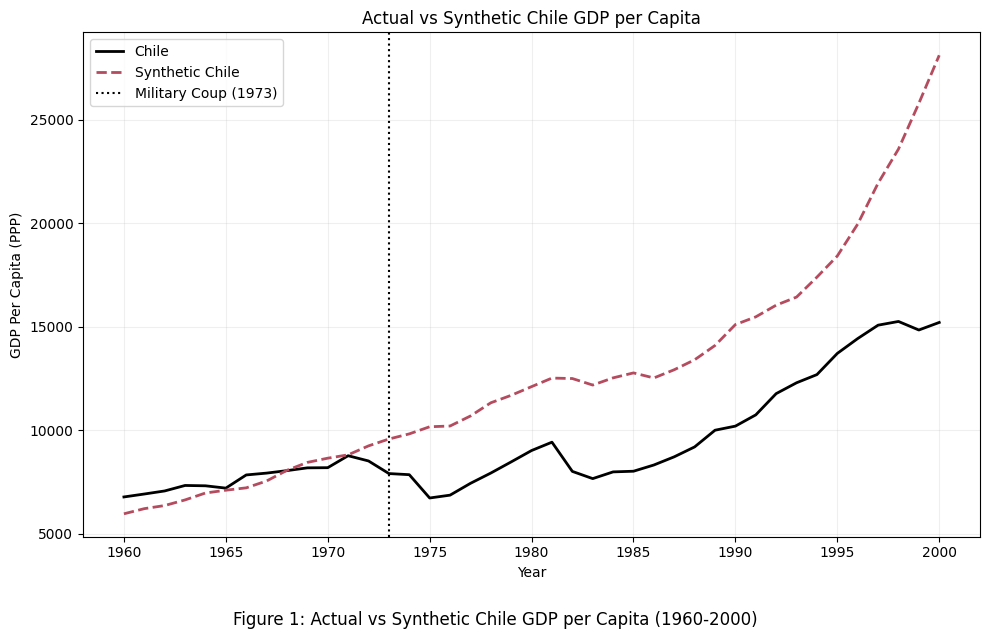

Saved figure: chile_actual_vs_synthetic.png


In [20]:
plt.figure(figsize=(10, 6))

# Actual Chile
plt.plot(
    gdp_comparison.index,
    gdp_comparison["Actual Chile"],
    color="black",
    linewidth=2,
    label="Chile"
)

# Synthetic Chile
plt.plot(
    gdp_comparison.index,
    gdp_comparison["Synthetic Chile"],
    linestyle="--",
    color="#b54b5e",
    linewidth=2,
    label="Synthetic Chile"
)

# Mark 1973 coup
plt.axvline(
    x=INTERVENTION_YEAR,
    linestyle=":",
    color="black",
    linewidth=1.5,
    label="Military Coup (1973)"
)

# X-axis ticks every 5 years
years = np.arange(PRE_TREATMENT_START, POST_TREATMENT_END + 5, 5)
plt.xticks(years)

# Labels
plt.xlabel("Year")
plt.ylabel("GDP Per Capita (PPP)")
plt.title("Actual vs Synthetic Chile GDP per Capita")

# Legend and grid
plt.legend()
plt.grid(alpha=0.2)

# Figure caption
plt.figtext(
    0.5,
    -0.05,
    "Figure 1: Actual vs Synthetic Chile GDP per Capita (1960-2000)",
    ha="center",
    fontsize=12
)

plt.tight_layout()
plt.savefig("chile_actual_vs_synthetic.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure: chile_actual_vs_synthetic.png")

# Calculate Post-Treatment Effects
Although the visual comparison shows how the gap between Chile and Synthetic Chile evolves over time, it is also useful to quantify the magnitude of the treatment effect. Following the Colombia study's approach, I calculate the average GDP gap during the post-treatment period (1973-2000) to summarize the overall economic impact associated with the military coup and subsequent Pinochet regime. A negative gap indicates that Chile's observed GDP per capita fell below the synthetic counterfactual, suggesting an economic cost of the intervention.

In [21]:
# Separate the comparison into pre-treatment and post-treatment periods
pre_treatment_comparison = gdp_comparison.loc[PRE_TREATMENT_START:PRE_TREATMENT_END]
post_treatment_comparison = gdp_comparison.loc[INTERVENTION_YEAR:POST_TREATMENT_END]

print(f"Pre-treatment period: {PRE_TREATMENT_START}-{PRE_TREATMENT_END} ({len(pre_treatment_comparison)} years)")
print(f"Post-treatment period: {INTERVENTION_YEAR}-{POST_TREATMENT_END} ({len(post_treatment_comparison)} years)")

# Calculate average GDP gap in pre-treatment period (should be close to zero)
avg_pre_gap = pre_treatment_comparison["Gap"].mean()
print(f"\nAverage pre-treatment gap: ${avg_pre_gap:,.2f}")

# Calculate average GDP gap in post-treatment period (treatment effect)
avg_post_gap = post_treatment_comparison["Gap"].mean()
print(f"Average post-treatment gap: ${avg_post_gap:,.2f}")

# Express as percentage of actual GDP
avg_chile_gdp_post = post_treatment_comparison["Actual Chile"].mean()
gap_percentage = (avg_post_gap / avg_chile_gdp_post) * 100

print(f"Average post-treatment gap as % of GDP: {gap_percentage:+.2f}%")

if avg_post_gap < 0:
    print(f"\nInterpretation: Chile's GDP per capita averaged ${abs(avg_post_gap):,.0f} below")
    print(f"the synthetic counterfactual during 1973-2000, representing approximately")
    print(f"{abs(gap_percentage):.1f}% of actual GDP.")
else:
    print(f"\nInterpretation: Chile's GDP per capita averaged ${abs(avg_post_gap):,.0f} above")
    print(f"the synthetic counterfactual during 1973-2000, representing approximately")
    print(f"{abs(gap_percentage):.1f}% of actual GDP.")

Pre-treatment period: 1960-1972 (13 years)
Post-treatment period: 1973-2000 (28 years)

Average pre-treatment gap: $220.64
Average post-treatment gap: $-4,768.77
Average post-treatment gap as % of GDP: -46.71%

Interpretation: Chile's GDP per capita averaged $4,769 below
the synthetic counterfactual during 1973-2000, representing approximately
46.7% of actual GDP.


# Calculate Cumulative GDP Impact
I summarized the total economic impact across the full post-treatment period. Following the Colombia study's methodology, I calculate the cumulative GDP difference by summing the yearly gaps between Chile's observed GDP per capita and the synthetic counterfactual from 1973 to 2000. Because the gap is defined as observed minus synthetic GDP, negative cumulative values indicate total GDP loss while positive values indicate GDP gains relative to the counterfactual trajectory.

In [22]:
# Calculate cumulative gap over post-treatment period
cumulative_gap = post_treatment_comparison["Gap"].sum()

print(f"Cumulative GDP gap (1973-2000): ${cumulative_gap:,.0f}")

if cumulative_gap < 0:
    cumulative_loss = abs(cumulative_gap)
    print(f"\nThis represents a cumulative GDP loss of ${cumulative_loss:,.0f} per capita")
    print(f"over the {len(post_treatment_comparison)}-year post-treatment period.")
else:
    cumulative_gain = cumulative_gap
    print(f"\nThis represents a cumulative GDP gain of ${cumulative_gain:,.0f} per capita")
    print(f"over the {len(post_treatment_comparison)}-year post-treatment period.")

# Display key years for context
print("\nGDP comparison at selected years:")
key_years = [1972, 1973, 1980, 1990, 2000]
for year in key_years:
    if year in gdp_comparison.index:
        actual = gdp_comparison.loc[year, "Actual Chile"]
        synthetic = gdp_comparison.loc[year, "Synthetic Chile"]
        gap = gdp_comparison.loc[year, "Gap"]
        print(f"  {year}: Actual=${actual:,.0f}, Synthetic=${synthetic:,.0f}, Gap=${gap:,.0f}")

Cumulative GDP gap (1973-2000): $-133,526

This represents a cumulative GDP loss of $133,526 per capita
over the 28-year post-treatment period.

GDP comparison at selected years:
  1972: Actual=$8,520, Synthetic=$9,248, Gap=$-728
  1973: Actual=$7,911, Synthetic=$9,580, Gap=$-1,669
  1980: Actual=$9,024, Synthetic=$12,111, Gap=$-3,087
  1990: Actual=$10,203, Synthetic=$15,109, Gap=$-4,906
  2000: Actual=$15,212, Synthetic=$28,120, Gap=$-12,908


# Figure: Treatment Effect Over Time
The figure below shows the annual per-capita GDP gap, defined as Chile's observed GDP per capita minus Synthetic Chile's predicted GDP per capita. During the pre-treatment period (1960-1972), the gap fluctuates around zero, indicating that the synthetic control reproduces Chile's economic trajectory prior to the military coup. Following 1973, the gap becomes negative, suggesting that Chile's observed GDP per capita falls below the level predicted by the synthetic control.

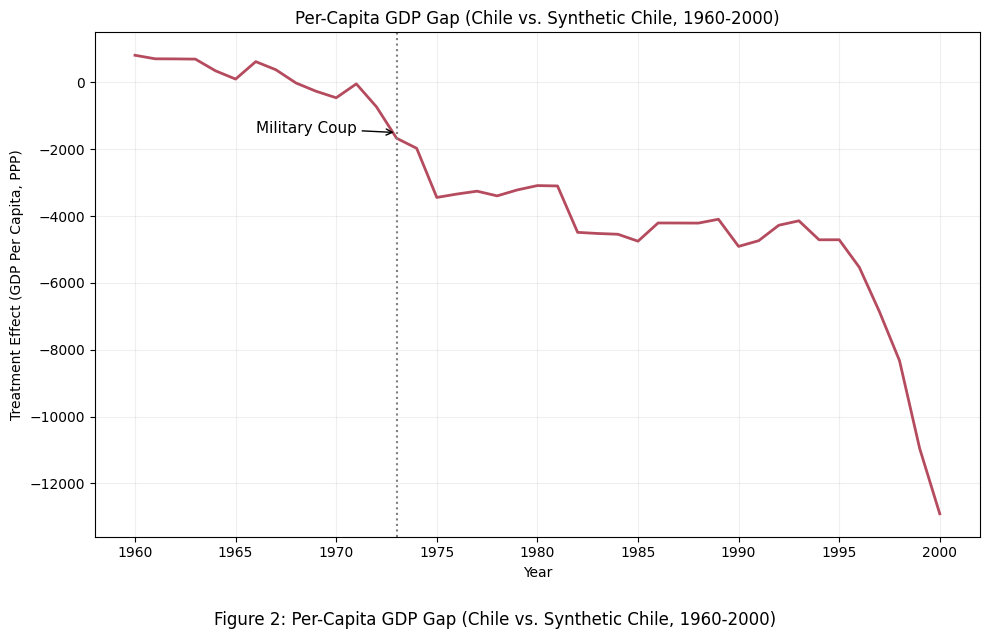

Saved figure: chile_gdp_gap.png


In [23]:
# Calculate the per-capita GDP gap
gdp_gap = gdp_comparison["Actual Chile"] - gdp_comparison["Synthetic Chile"]

# Create figure
plt.figure(figsize=(10, 6))

# Plot the GDP gap
plt.plot(
    gdp_gap.index,
    gdp_gap,
    color="#b54b5e",
    linewidth=2
)

# Mark 1973 coup with vertical line
plt.axvline(
    INTERVENTION_YEAR,
    linestyle=":",
    color="gray",
    linewidth=1.5
)

# Add annotation
plt.annotate(
    "Military Coup",
    xy=(1973, -1500),
    xytext=(1966, -1500),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=11
)

# X-axis ticks every 5 years
years = np.arange(PRE_TREATMENT_START, POST_TREATMENT_END + 5, 5)
plt.xticks(years)

# Labels
plt.xlabel("Year")
plt.ylabel("Treatment Effect (GDP Per Capita, PPP)")
plt.title("Per-Capita GDP Gap (Chile vs. Synthetic Chile, 1960-2000)")

# Grid and caption
plt.grid(True, alpha=0.2)
plt.figtext(
    0.5,
    -0.05,
    "Figure 2: Per-Capita GDP Gap (Chile vs. Synthetic Chile, 1960-2000)",
    ha="center",
    fontsize=12
)

plt.tight_layout()
plt.savefig("chile_gdp_gap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure: chile_gdp_gap.png")

# Limitations and Future Directions
The biggest technical hurdle in this analysis was constructing a donor pool that accurately reflects Chile's pre-intervention economic trajectory. Unlike in Milestone 2, where I replicated the Colombia study's established donor pool with known weights and predictor variables, this analysis required building the donor pool from scratch. The most challenging part was identifying which countries served as valid counterfactuals for Chile before 1973. This proved unexpectedly difficult because Chile's GDP per capita in 1972 ($8,520) placed it near the upper end of middle-income countries, making it wealthier than most Latin American comparators but following a different growth trajectory from rapidly developing European economies during the 1960s.

The synthetic control's upward bias during the late 1960s, where Synthetic Chile grows faster than actual Chile even before the 1973 coup, suggests the current donor pool (four European countries plus three Latin American countries) may not adequately capture Chile's pre-intervention economic dynamics. Several modifications were tested to improve pre-treatment fit quality. First, I added individual GDP years (1960, 1963, 1966, 1969, 1972) as separate predictors to force the algorithm to match Chile's trajectory at specific points in time instead of just its average level. Second, I removed Ireland from the donor pool, hypothesizing that Ireland's rapid Celtic Tiger growth might be pulling the synthetic trajectory upward. Third, I constructed an alternative specification using only Latin American donors (Colombia, Costa Rica, Mexico), reasoning that Chile's moderate growth might be more comparable to other Latin American countries than to European economies experiencing post-war economic miracles. None of these adjustments produced meaningful improvements in pre-treatment fit, with the Latin America-only specification actually yielding substantially worse fit quality due to reduced donor pool flexibility.

Future attempts will focus on expanding the predictor set to include additional economic and institutional variables beyond the current seven predictors, which may better capture Chile's pre-1973 characteristics. Revising the exclusion criteria to incorporate more Latin American countries, such as Argentina, Uruguay, and Brazil, may be another promising direction, though careful treatment-period definitions would be needed to avoid contamination from parallel political interventions in those countries during the 1970s.
Other matching approaches, including constrained donor weights and nested optimization procedures that jointly estimate predictor and donor weights, could also be explored. Despite these limitations, the analysis demonstrates the complete synthetic control workflow and provides suggestive evidence that Chile's observed GDP per capita fell below the level predicted by comparable donor countries during 1973-2000, though the pre-treatment fit issues suggest this estimate should be interpreted cautiously.
